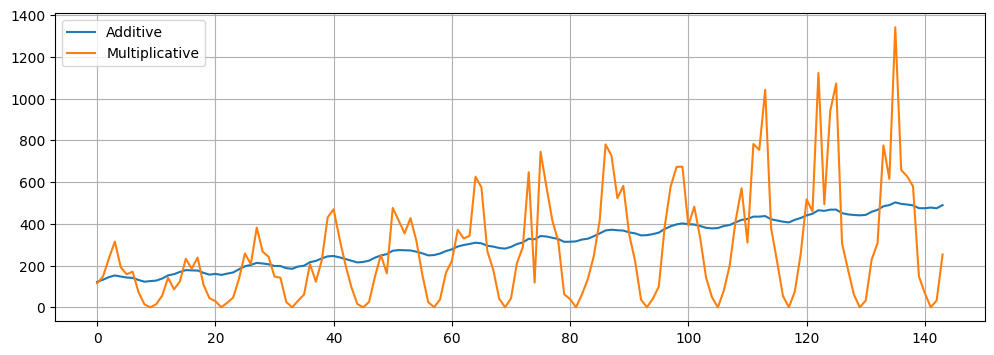

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time = np.arange(144)

seasonal_12 = 20 + np.sin(2*np.pi*time/12)*20
trend = time * 2.65 + 100
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))

# Аддитивная модель
y_add = trend + seasonal_12 + residuals

# Мультипликативная модель
# Важно: для мультипликативной сезонности удобно нормировать seasonal так, чтобы среднее было около 1,
# иначе сезонность станет "большим множителем" уровня ряда.
seasonal_mul = seasonal_12 / np.mean(seasonal_12)
y_mul = trend * seasonal_mul * (1 + residuals/10)+1e-4  # шум как относительный

# Визуализация
plt.figure(figsize=(12,4))
plt.plot(time, y_add, label="Additive")
plt.plot(time, y_mul, label="Multiplicative")
plt.legend(); plt.grid(True); plt.show()

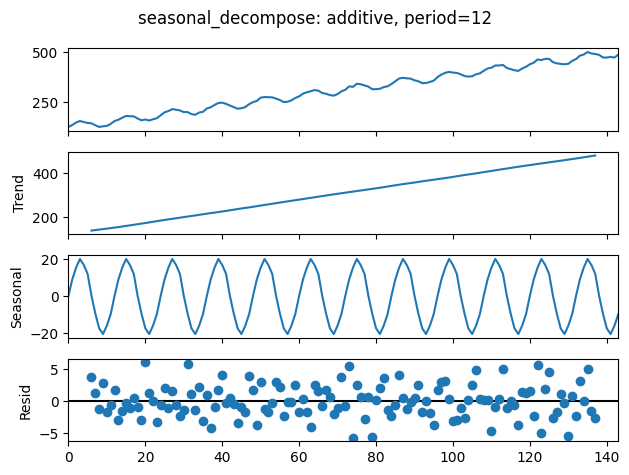

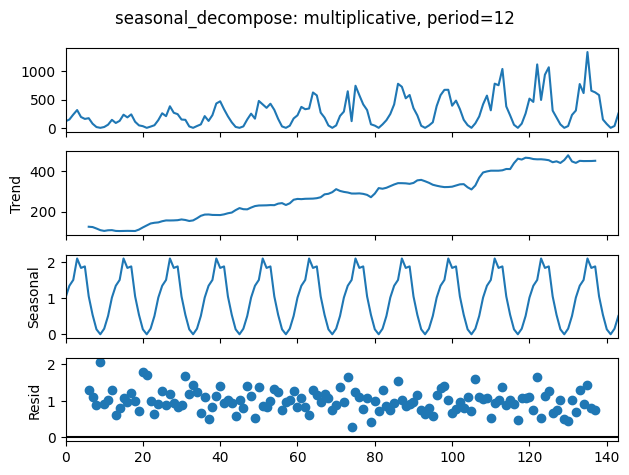

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL
# Для statsmodels лучше подавать Series, чтобы корректно работали индексы
s_add = pd.Series(y_add)
s_mul = pd.Series(y_mul)

dec_add = seasonal_decompose(s_add, model="additive", period=12)
dec_mul = seasonal_decompose(s_mul, model="multiplicative", period=12)
dec_add.plot()
plt.suptitle("seasonal_decompose: additive, period=12")
plt.tight_layout()
plt.show()

dec_mul.plot()
plt.suptitle("seasonal_decompose: multiplicative, period=12")
plt.tight_layout()
plt.show()